In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as transforms
import matplotlib.font_manager as fm
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ==========================
# 0. 全局字体与主题设置
# ==========================
# 强制使用 Arial 字体
arial_path = None
for f in fm.fontManager.ttflist:
    if 'Arial' in f.name and 'Italic' not in f.name and 'Bold' not in f.name:
        arial_path = f.fname
        break

if arial_path:
    prop = fm.FontProperties(fname=arial_path)
    plt.rcParams['font.family'] = prop.get_name()
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style="whitegrid")

# ==========================
# 1. 业务逻辑常量 (无需额外更改)
# ==========================
PRED_COLS = ['actdlkcat', 'actunikp', 'actturnup', 'actcatapro']
MODEL_NAMES = {
    'actdlkcat': 'DLKcat', 'actunikp': 'UniKP', 
    'actturnup': 'TurNuP', 'actcatapro': 'CataPro' # 修正Catapro为CataPro保持一致
}

ENZYME_ORDER = ['LeADH', 'SsADH', 'CPCR2', 'CpCAD', 'EcCAD', 'SsGDHM4', 'HLADH', 'TbADH', 'EcSDH', 'EcQOR', 'MtbQOR']
SUBSTRATE_ORDER = ["Aliphatic alcohols", "Saccharides & polyols", "Aromatic alcohols", "Heterocyclic alcohols", "Cyclohexanol derivatives", "Others"]
NAD_PREF_ENZYMES = ['LeADH', 'SsADH', 'CPCR2', 'CpCAD']
NADP_PREF_ENZYMES = ['TbADH', 'EcSDH', 'EcQOR']
COFACTOR_CATEGORIES = ['NAD (Global)', 'NADP (Global)', 'NAD\n(NAD-pref. enzymes)', 'NADP\n(NAD-pref. enzymes)', 'NAD\n(NADP-pref. enzymes)', 'NADP\n(NADP-pref. enzymes)']
METRICS_ORDER = ['TP', 'FN', 'TN', 'FP'] 

def classify_substrate(subnum):
    if 1 <= subnum <= 12: return "Aliphatic alcohols"
    elif 13 <= subnum <= 20: return "Saccharides & polyols"
    elif 21 <= subnum <= 24: return "Aromatic alcohols"
    elif 25 <= subnum <= 28: return "Heterocyclic alcohols"
    elif 29 <= subnum <= 32: return "Cyclohexanol derivatives"
    elif 33 <= subnum <= 36: return "Others"
    else: return "Unknown"

def find_best_threshold(y_true_bin, y_pred_cont):
    thresholds = np.unique(y_pred_cont)
    if len(thresholds) > 1000: thresholds = np.linspace(y_pred_cont.min(), y_pred_cont.max(), 1000)
    best_f1, best_thresh = -1, 0
    for thresh in thresholds:
        y_pred_bin = (y_pred_cont >= thresh).astype(int)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        if f1 > best_f1: best_f1, best_thresh = f1, thresh
    return best_thresh

def calculate_confusion_rates(y_true_bin, y_pred_bin):
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]).ravel()
    total = tp + tn + fp + fn
    if total == 0: return {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0, 'Total': 0}
    return {'TP': tp/total, 'TN': tn/total, 'FP': fp/total, 'FN': fn/total, 'Total': total}

# ==========================
# 2. 读取数据与预处理
# ==========================
SAVE_DIR = "analysis_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_excel("sum.xlsx")
if 'substrate_class' not in df.columns and 'subnum' in df.columns:
    df['substrate_class'] = df['subnum'].apply(classify_substrate)

valid_models = [col for col in PRED_COLS if col in df.columns]

print("【计算全局最佳 F1 阈值】")
best_thresholds = {}
for col in valid_models:
    mask = ~df[col].isna() & ~df['actbool'].isna()
    thresh = find_best_threshold(df.loc[mask, 'actbool'].values, df.loc[mask, col].values)
    best_thresholds[col] = thresh
    print(f"▶ {MODEL_NAMES[col]}: {thresh:.4f}")

# 预计算数据供后续 Cell 使用
valid_data_dict = {} 
enzyme_dfs_dict = {} 
substrate_dfs_dict = {}
cofactor_dfs_dict = {}

for col in valid_models:
    thresh = best_thresholds[col]
    mask = ~df[col].isna() & ~df['actbool'].isna()
    df_valid = df[mask].copy()
    df_valid['pred_bin'] = (df_valid[col] >= thresh).astype(int)
    y_true = df_valid['actbool'].values
    y_pred = df_valid['pred_bin'].values
    valid_data_dict[col] = df_valid 
    
    # Enzyme
    enz_stats = []
    for enz in ENZYME_ORDER:
        enz_mask = df_valid['enzyme'] == enz
        if enz_mask.sum() == 0: continue
        rates = calculate_confusion_rates(y_true[enz_mask], y_pred[enz_mask])
        rates['Category'] = enz
        enz_stats.append(rates)
    enzyme_dfs_dict[col] = pd.DataFrame(enz_stats).set_index('Category').reindex(ENZYME_ORDER).fillna(0)
    
    # Substrate
    sub_stats = []
    for sub in SUBSTRATE_ORDER:
        sub_mask = df_valid['substrate_class'] == sub
        if sub_mask.sum() == 0: continue
        rates = calculate_confusion_rates(y_true[sub_mask], y_pred[sub_mask])
        rates['Category'] = sub
        sub_stats.append(rates)
    substrate_dfs_dict[col] = pd.DataFrame(sub_stats).set_index('Category').reindex(SUBSTRATE_ORDER).fillna(0)
    
    # Cofactor
    cof_stats = []
    for cof in ['NAD', 'NADP']:
        cof_mask = df_valid['cofactor'] == cof
        if cof_mask.sum() == 0: continue
        rates = calculate_confusion_rates(y_true[cof_mask], y_pred[cof_mask])
        rates['Category'] = f"{cof} (Global)"
        cof_stats.append(rates)
    nad_pref_mask = df_valid['enzyme'].isin(NAD_PREF_ENZYMES)
    for cof in ['NAD', 'NADP']:
        mask_subset = nad_pref_mask & (df_valid['cofactor'] == cof)
        if mask_subset.sum() == 0: continue
        rates = calculate_confusion_rates(y_true[mask_subset], y_pred[mask_subset])
        rates['Category'] = f"{cof}\n(NAD-pref. enzymes)"
        cof_stats.append(rates)
    nadp_pref_mask = df_valid['enzyme'].isin(NADP_PREF_ENZYMES)
    for cof in ['NAD', 'NADP']:
        mask_subset = nadp_pref_mask & (df_valid['cofactor'] == cof)
        if mask_subset.sum() == 0: continue
        rates = calculate_confusion_rates(y_true[mask_subset], y_pred[mask_subset])
        rates['Category'] = f"{cof}\n(NADP-pref. enzymes)"
        cof_stats.append(rates)
    cofactor_dfs_dict[col] = pd.DataFrame(cof_stats).set_index('Category').reindex(COFACTOR_CATEGORIES).fillna(0)

print("✅ Cell 1 准备工作完成，数据已就绪。")

【计算全局最佳 F1 阈值】
▶ DLKcat: 4.3534
▶ UniKP: 6.6042
▶ TurNuP: 9.9700
▶ CataPro: 1.3055
✅ Cell 1 准备工作完成，数据已就绪。



【绘制 FS3: 绝对等宽层级分析大图】


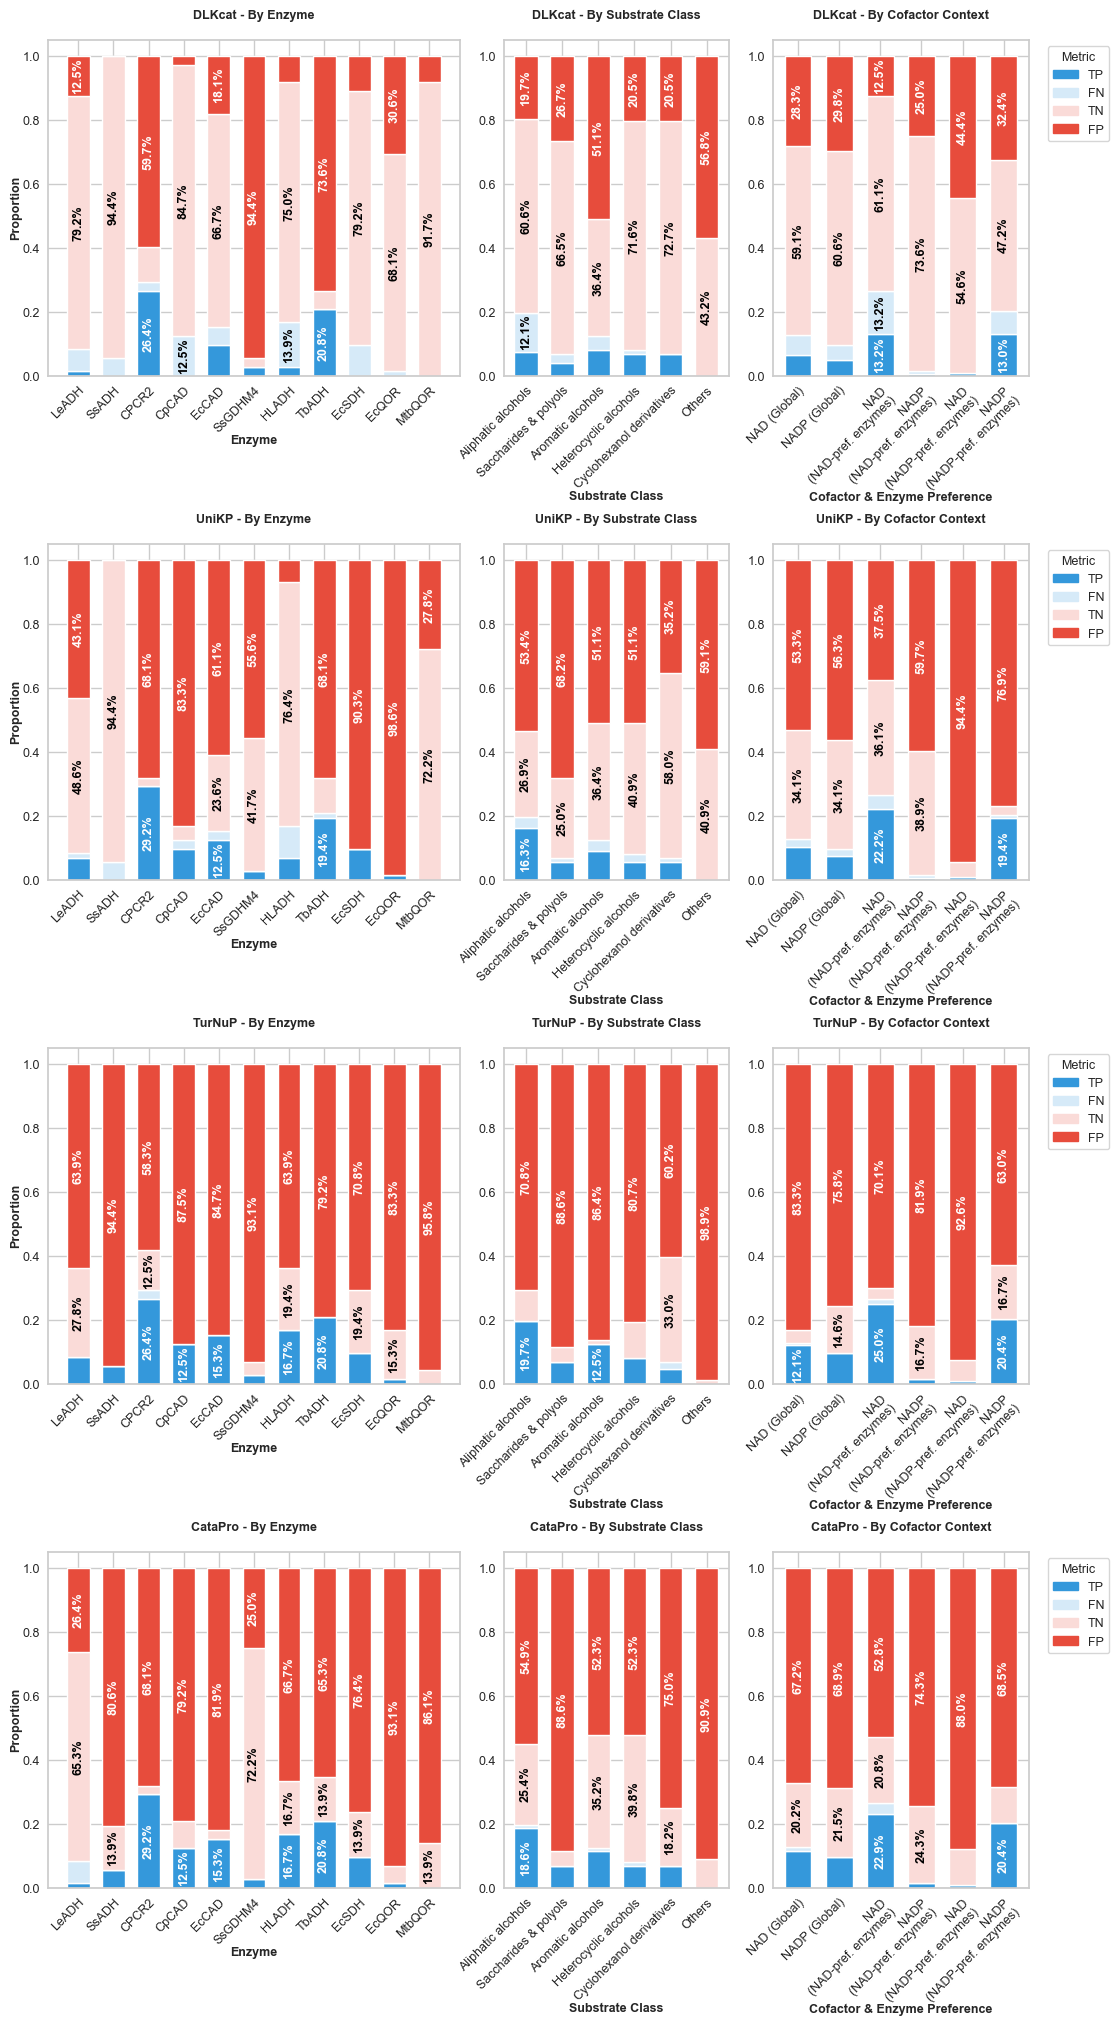

✅ FS3 已保存: figures\FS3.png & figures\FS3.tif


In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_stacked_bar(ax, df_plot, title, CONFIG, show_ylabel=False):
    bottoms = np.zeros(len(df_plot))
    bar_width = 0.65 
    for metric in METRICS_ORDER:
        values = df_plot[metric].values
        ax.bar(range(len(df_plot)), values, bottom=bottoms, color=CONFIG['color_map'][metric], 
               edgecolor='white', width=bar_width, label=metric)
        
        # 【优化】：仅保留大于阈值的数值，垂直显示并保证绝对居中
        for i, (val, bottom) in enumerate(zip(values, bottoms)):
            if val > CONFIG['bar_text_threshold']: 
                # 垂直居中：底部位置 + 色块高度的一半
                y_pos = bottom + val / 2
                text_color = 'white' if metric in ['TP', 'FP'] else 'black'
                ax.text(i, y_pos, f'{val*100:.1f}%', ha='center', va='center', 
                        fontsize=CONFIG['font_bar_text'], fontweight='bold', color=text_color,
                        rotation=90, rotation_mode='anchor') # 垂直显示并锚点居中
        bottoms += values

    ax.set_title(title, fontsize=CONFIG['font_title'], fontweight='bold', pad=15)
    
    # 应用 Y 轴标签与间距
    if show_ylabel:
        ax.set_ylabel("Proportion", fontsize=CONFIG['font_axis_label'], fontweight='bold', labelpad=CONFIG['ylabel_pad'])
    else:
        ax.set_ylabel("")
        
    ax.set_ylim(0, 1.05) 
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    
    # 应用刻度字号与间距
    ax.tick_params(axis='y', labelsize=CONFIG['font_tick'], pad=CONFIG['ytick_pad'])
    ax.tick_params(axis='x', labelsize=CONFIG['font_tick'], pad=CONFIG['xtick_pad'])
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels(df_plot.index, rotation=45, ha='right', rotation_mode='anchor')

def plot_stacked_bar_with_labels(ax, df_plot, title, xlabel, CONFIG, show_ylabel=False, show_legend=False):
    plot_stacked_bar(ax, df_plot, title, CONFIG, show_ylabel=show_ylabel)
    # 应用 X 轴标签与间距
    ax.set_xlabel(xlabel, fontsize=CONFIG['font_axis_label'], fontweight='bold', labelpad=CONFIG['xlabel_pad'])
    if show_legend:
        handles = [mpatches.Patch(color=CONFIG['color_map'][m], label=m) for m in METRICS_ORDER]
        ax.legend(handles=handles, title="Metric", bbox_to_anchor=(1.05, 1), 
                  loc='upper left', fontsize=CONFIG['font_legend'], title_fontsize=CONFIG['font_legend_title'], frameon=True)

def plot_FS3(CONFIG):
    print("\n【绘制 FS3: 绝对等宽层级分析大图】")
    SAVE_DIR = "figures"
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    n_models = len(valid_models)
    width_enz = len(ENZYME_ORDER) * CONFIG['fs3_inches_per_bar']
    width_sub = len(SUBSTRATE_ORDER) * CONFIG['fs3_inches_per_bar']
    width_cof = len(COFACTOR_CATEGORIES) * CONFIG['fs3_inches_per_bar'] + CONFIG['fs3_inches_per_legend']
    total_fig_width = CONFIG['fs3_margin_left'] + width_enz + CONFIG['fs3_subplot_gap'] + width_sub + CONFIG['fs3_subplot_gap'] + width_cof + CONFIG['fs3_margin_right']
    fig_height = 6 * n_models
    
    fig = plt.figure(figsize=(total_fig_width, fig_height))
    gs = fig.add_gridspec(n_models, 3, width_ratios=[width_enz, width_sub, width_cof], wspace=0.15, hspace=0.5)
    
    for i, col in enumerate(valid_models):
        model_name = MODEL_NAMES[col]
        ax1 = fig.add_subplot(gs[i, 0])
        plot_stacked_bar_with_labels(ax1, enzyme_dfs_dict[col], f"{model_name} - By Enzyme", "Enzyme", CONFIG, show_ylabel=True)
        
        ax2 = fig.add_subplot(gs[i, 1])
        plot_stacked_bar_with_labels(ax2, substrate_dfs_dict[col], f"{model_name} - By Substrate Class", "Substrate Class", CONFIG)
        
        ax3 = fig.add_subplot(gs[i, 2])
        plot_stacked_bar_with_labels(ax3, cofactor_dfs_dict[col], f"{model_name} - By Cofactor Context", "Cofactor & Enzyme Preference", CONFIG, show_legend=True)

    fig_path_png = os.path.join(SAVE_DIR, "FS3.png")
    fig_path_tif = os.path.join(SAVE_DIR, "FS3.tif")
    plt.savefig(fig_path_png, dpi=CONFIG['fs3_dpi'], bbox_inches='tight')
    plt.savefig(fig_path_tif, dpi=CONFIG['fs3_dpi'], bbox_inches='tight')
    plt.show()
    print(f"✅ FS3 已保存: {fig_path_png} & {fig_path_tif}")

# ================= FS3 独立配置 =================
CONFIG_FS3 = {
    'color_map': {'TP': '#3498db', 'FN': '#D6EAF8', 'TN': '#FADBD8', 'FP': '#e74c3c'},
    'font_title': 9, 'font_axis_label': 9, 'font_tick': 9, 
    'font_bar_text': 9, 'font_legend': 9, 'font_legend_title': 9,
    'bar_text_threshold': 0.12,  # 【新增】仅显示大于 12% 的数值
    'xtick_pad': 0, 'ytick_pad': 0, 'xlabel_pad': 0, 'ylabel_pad': 0, # 【新增】间距控制
    'fs3_inches_per_bar': 0.3, 'fs3_inches_per_legend': 0.25, 
    'fs3_subplot_gap': 1.5, 'fs3_margin_left': 1.5, 'fs3_margin_right': 1.0, 'fs3_dpi': 300,
}

plot_FS3(CONFIG_FS3)


【绘制 Figure4: 2x2 Enzyme 差异组堆叠图】


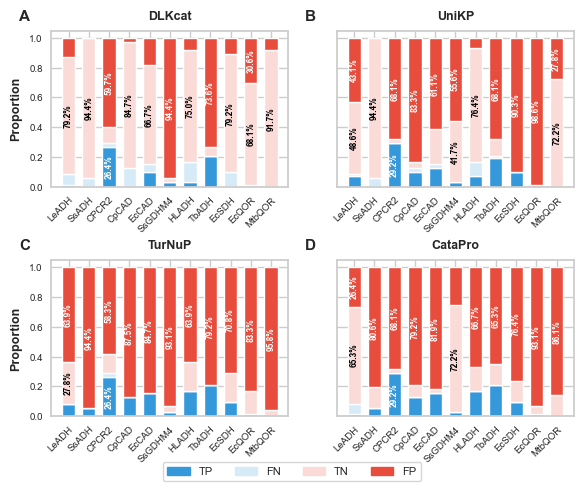

✅ Figure4 已保存: figures\Figure4.png & figures\Figure4.tif


In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.transforms as transforms

# ================= 内置绘图辅助函数 (确保 Cell3 独立运行) =================
def plot_stacked_bar(ax, df_plot, title, CONFIG, show_ylabel=False):
    bottoms = np.zeros(len(df_plot))
    bar_width = 0.65 
    for metric in METRICS_ORDER:
        values = df_plot[metric].values
        ax.bar(range(len(df_plot)), values, bottom=bottoms, color=CONFIG['color_map'][metric], 
               edgecolor='white', width=bar_width, label=metric)
        
        # 仅保留大于阈值的数值，垂直显示并绝对居中
        for i, (val, bottom) in enumerate(zip(values, bottoms)):
            if val > CONFIG['bar_text_threshold']: 
                y_pos = bottom + val / 2
                text_color = 'white' if metric in ['TP', 'FP'] else 'black'
                ax.text(i, y_pos, f'{val*100:.1f}%', ha='center', va='center', 
                        fontsize=CONFIG['font_bar_text'], fontweight='bold', color=text_color,
                        rotation=90, rotation_mode='anchor')
        bottoms += values

    ax.set_title(title, fontsize=CONFIG['font_title'], fontweight='bold', pad=CONFIG['title_pad'])
    
    if show_ylabel:
        ax.set_ylabel("Proportion", fontsize=CONFIG['font_axis_label'], fontweight='bold', labelpad=CONFIG['ylabel_pad'])
    else:
        ax.set_ylabel("")
        
    ax.set_ylim(0, 1.05) 
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    
    ax.tick_params(axis='y', labelsize=CONFIG['font_tick'], pad=CONFIG['ytick_pad'])
    ax.tick_params(axis='x', labelsize=CONFIG['font_tick'], pad=CONFIG['xtick_pad'])
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels(df_plot.index, rotation=45, ha='right', rotation_mode='anchor')

def add_subplot_label(ax, label, fig, CONFIG):
    offset = transforms.ScaledTranslation(CONFIG['label_dx_pts']/72, CONFIG['label_dy_pts']/72, fig.dpi_scale_trans)
    trans = ax.transAxes + offset
    ax.text(0, 1.0, label, transform=trans, fontsize=CONFIG['label_fontsize'], fontweight='bold', va='bottom', ha='right')

# ================= 核心绘图逻辑 =================
def plot_Figure4(CONFIG):
    print("\n【绘制 Figure4: 2x2 Enzyme 差异组堆叠图】")
    SAVE_DIR = "figures"
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    fig_enz, axes_enz = plt.subplots(2, 2, figsize=(CONFIG['fig4_width'], CONFIG['fig4_height']), sharey=True)
    axes_enz_flat = axes_enz.flatten()
    labels = ['A', 'B', 'C', 'D']

    for idx, col in enumerate(valid_models):
        if idx >= 4: break 
        model_name = MODEL_NAMES[col]
        df_enz = enzyme_dfs_dict[col]
        ax_e = axes_enz_flat[idx]
        
        plot_stacked_bar(ax_e, df_enz, f"{model_name}", CONFIG, show_ylabel=(idx % 2 == 0))
        ax_e.set_xlabel("") 
        add_subplot_label(ax_e, labels[idx], fig_enz, CONFIG)
        
    for idx in range(len(valid_models), 4):
        axes_enz_flat[idx].set_visible(False)

    handles = [mpatches.Patch(color=CONFIG['color_map'][m], label=m) for m in METRICS_ORDER]
    
    # 【优化】：应用图例垂直距离参数
    fig_enz.legend(handles=handles, loc='lower center', ncol=4, 
                   fontsize=CONFIG['font_legend'], frameon=True, 
                   bbox_to_anchor=(0.5, CONFIG['legend_y_anchor']))

    # 【优化】：应用子图底部留白参数，防止图例被裁切
    plt.tight_layout(rect=[0, CONFIG['layout_bottom_margin'], 1, 0.98], 
                     w_pad=CONFIG['w_pad'], h_pad=CONFIG['h_pad'])
    
    fig_path_png = os.path.join(SAVE_DIR, "Figure4.png")
    fig_path_tif = os.path.join(SAVE_DIR, "Figure4.tif")
    fig_enz.savefig(fig_path_png, dpi=CONFIG['fig_dpi'], bbox_inches='tight')
    fig_enz.savefig(fig_path_tif, dpi=CONFIG['fig_dpi'], bbox_inches='tight')
    plt.show()
    print(f"✅ Figure4 已保存: {fig_path_png} & {fig_path_tif}")

# ================= Figure4 独立配置 =================
CONFIG_FIG4 = {
    # ================= 统一色号 =================
    'color_map': {'TP': '#3498db', 'FN': '#D6EAF8', 'TN': '#FADBD8', 'FP': '#e74c3c'},
    
    # ================= 字号控制 =================
    'font_title': 9, 'font_axis_label': 9, 'font_tick': 7, 
    'font_bar_text': 6,          # 【选项】柱上数字大小
    'font_legend': 8,            # 【选项】图例字号
    'font_legend_title': 9,      # (保留参数，当前图例无标题)
    
    # ================= 间距与阈值控制 =================
    'bar_text_threshold': 0.25,  # 【选项】仅显示大于 25% 的数值
    'title_pad': 8,              # 【选项】图题与坐标轴的距离
    
    'xtick_pad': 0, 'ytick_pad': 0, 'xlabel_pad': 0, 'ylabel_pad': 5, # 刻度/标签间距
    
    'w_pad': 1,                  # 【选项】子图之间的水平间距
    'h_pad': 0.3,                # 【选项】子图之间的垂直间距
    
    # ================= 图例与图距离控制 (新增) =================
    'legend_y_anchor': -0.01,    # 【选项】图例垂直锚点 (负值向下，值越小离图越远)
    'layout_bottom_margin': 0.00,# 【选项】子图区域底部留白比例 (需配合图例下移增大，防裁切)
    
    # ================= 图号 A/B/C/D 定位 =================
    'label_dx_pts': -15, 'label_dy_pts': 5, 'label_fontsize': 11,
    
    # ================= 画布与保存设置 =================
    'fig_dpi': 300, 'fig4_width': 6, 'fig4_height': 5,
}

plot_Figure4(CONFIG_FIG4)


【绘制 Figure5: 2x2 组合小提琴图】


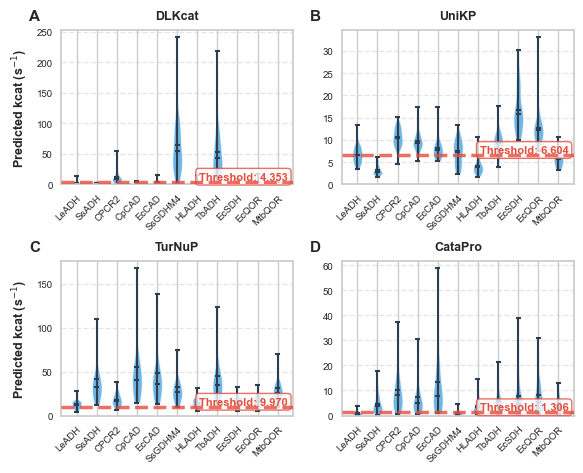

✅ Figure5 已保存: figures\Figure5.png & figures\Figure5.tif


In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms

# ================= 内置绘图辅助函数 (确保 Cell4 独立运行) =================
def add_subplot_label(ax, label, fig, CONFIG):
    offset = transforms.ScaledTranslation(CONFIG['label_dx_pts']/72, CONFIG['label_dy_pts']/72, fig.dpi_scale_trans)
    trans = ax.transAxes + offset
    ax.text(0, 1.0, label, transform=trans, fontsize=CONFIG['label_fontsize'], fontweight='bold', va='bottom', ha='right')

# ================= 核心绘图逻辑 =================
def plot_Figure5(CONFIG):
    print("\n【绘制 Figure5: 2x2 组合小提琴图】")
    SAVE_DIR = "figures"
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    fig_v, axes_v = plt.subplots(2, 2, figsize=(CONFIG['fig5_width'], CONFIG['fig5_height']), sharey=False)
    axes_v_flat = axes_v.flatten()
    labels = ['A', 'B', 'C', 'D']

    for idx, col in enumerate(valid_models):
        if idx >= 4: break
        model_name = MODEL_NAMES[col]
        df_valid = valid_data_dict[col]
        thresh = best_thresholds[col] 
        ax_v = axes_v_flat[idx]
        
        df_violin = df_valid[['enzyme', col]].copy()
        df_violin[col] = pd.to_numeric(df_violin[col], errors='coerce').dropna()
        
        valid_enz_indices, valid_plot_data = [], []
        for i, enz in enumerate(ENZYME_ORDER):
            data = df_violin[df_violin['enzyme'] == enz][col].values
            if len(data) > 1:  
                valid_enz_indices.append(i)
                valid_plot_data.append(data)
        
        if len(valid_plot_data) > 0:
            parts = ax_v.violinplot(valid_plot_data, positions=valid_enz_indices, showmeans=True, showmedians=True)
            for pc in parts['bodies']:
                pc.set_facecolor(CONFIG['violin_color'])
                pc.set_alpha(CONFIG['violin_alpha'])
            for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
                if partname in parts:
                    parts[partname].set_edgecolor(CONFIG['violin_edge_color'])
                    parts[partname].set_linewidth(1.5)

        ax_v.set_ylim(bottom=0) 
        ax_v.axhline(y=thresh, color=CONFIG['thresh_line_color'], linestyle='--', linewidth=2.5, zorder=10, alpha=0.8)
        ax_v.text(len(ENZYME_ORDER) - 0.5, thresh, f'Threshold: {thresh:.3f}', 
                  va='bottom', ha='right', color=CONFIG['thresh_line_color'], fontsize=CONFIG['font_threshold'], fontweight='bold',
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=CONFIG['thresh_line_color'], alpha=0.8))

        # 【优化】：应用图题与坐标轴的距离参数
        ax_v.set_title(f'{model_name}', fontsize=CONFIG['font_title'], fontweight='bold', pad=CONFIG['title_pad'])
        ax_v.set_xticks(range(len(ENZYME_ORDER)))
        ax_v.set_xticklabels(ENZYME_ORDER, rotation=45, ha='right', rotation_mode='anchor', fontsize=CONFIG['font_tick'])
        
        # 应用刻度字号与间距
        ax_v.tick_params(axis='y', labelsize=CONFIG['font_tick'], pad=CONFIG['ytick_pad'])
        ax_v.tick_params(axis='x', labelsize=CONFIG['font_tick'], pad=CONFIG['xtick_pad'])
        ax_v.grid(axis='y', linestyle='--', alpha=0.5)
        ax_v.set_xlabel("", labelpad=CONFIG['xlabel_pad']) # 保持参数结构一致
        
        if idx % 2 == 0:
            ax_v.set_ylabel('Predicted kcat (s$^{-1}$)', fontsize=CONFIG['font_axis_label'], fontweight='bold', labelpad=CONFIG['ylabel_pad'])
        else:
            ax_v.set_ylabel("")
            
        add_subplot_label(ax_v, labels[idx], fig_v, CONFIG)

    for idx in range(len(valid_models), 4):
        axes_v_flat[idx].set_visible(False)

    # 【优化】：使用 w_pad 和 h_pad 精准控制图间距
    plt.tight_layout(rect=[0, 0, 1, 0.98], w_pad=CONFIG['w_pad'], h_pad=CONFIG['h_pad'])
    
    fig_path_png = os.path.join(SAVE_DIR, "Figure5.png")
    fig_path_tif = os.path.join(SAVE_DIR, "Figure5.tif")
    fig_v.savefig(fig_path_png, dpi=CONFIG['fig_dpi'], bbox_inches='tight')
    fig_v.savefig(fig_path_tif, dpi=CONFIG['fig_dpi'], bbox_inches='tight')
    plt.show()
    print(f"✅ Figure5 已保存: {fig_path_png} & {fig_path_tif}")

# ================= Figure5 独立配置 =================
CONFIG_FIG5 = {
    # ================= 字号控制 =================
    'font_title': 9, 
    'font_axis_label': 9, 
    'font_tick': 7, 
    'font_threshold': 8,         # 阈值标注文字大小
    
    # ================= 间距控制 (与 Cell3 对齐) =================
    'title_pad': 8,              # 【选项】图题与坐标轴的距离
    'xtick_pad': 0,              # 【选项】X轴刻度与轴线间距
    'ytick_pad': 0,              # 【选项】Y轴刻度与轴线间距
    'xlabel_pad': 0,             # 【选项】X轴标签与刻度间距 (当前隐藏X轴标签)
    'ylabel_pad': 5,             # 【选项】Y轴标签与刻度间距
    
    'w_pad': 1.0,                # 【选项】子图之间的水平间距
    'h_pad': 0.5,                # 【选项】子图之间的垂直间距
    
    # ================= 图号 A/B/C/D 定位 =================
    'label_dx_pts': -15, 
    'label_dy_pts': 5, 
    'label_fontsize': 11,
    
    # ================= 画布与保存设置 =================
    'fig_dpi': 300, 
    'fig5_width': 6, 
    'fig5_height': 5,
    
    # ================= 小提琴图专属配色 =================
    'violin_color': '#3498db', 
    'violin_alpha': 0.7, 
    'violin_edge_color': '#2c3e50', 
    'thresh_line_color': '#e74c3c'
}

plot_Figure5(CONFIG_FIG5)